# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 7


### Zadanie 1

W mieście liczącym 700 000 mieszkańców pojawiła się choroba, na którą choruje 1 osoba na 1000. Nie wiadomo, które osoby są chore, ale dostępny jest test diagnostyczny, którego zarówno czułość i swoistość wynosi 99% (tzn. prawdopodobieństwo uzyskania poprawnego wyniku – zarówno pozytywnego u osoby chorej, jak i negatywnego u osoby zdrowej – wynosi 99%).
Jakie jest prawdopodobieństwo, że pacjent, który otrzymał pozytywny wynik testu jest rzeczywiście chory?

#### A)

Przeprowadź symulację komputerową opisanego scenariusza:

- Utwórz listę mieszkańców o wielkości 700 tys. elementów, gdzie każdy element reprezentuje mieszkańca. Każdy mieszkaniec powinien posiadać dwie właściwości: *stan zdrowia* (zdrowy/chory) oraz *wynik diagnozy* (pozytywny/negatywny).
- Losowo wybieramy 700 mieszkańców (bo 1 na 1000 osób choruje) i przypisz im *stan zdrowia* jako *chory*. Uwaga: należy dopilnować, aby nie wylosowała się dwukrotnie ta sama osoba.
- Spośród osób chorych wylosuj 1% i przypisz im błędny wynik testu (*wynik diagnozy* = negatywny). Spośród osób zdrowych wylosuj 1% i przypisz im błędny wynik testu (*wynik diagnozy* = pozytywny).
- Korzystając z utworzonej listy mieszkańców, oblicz prawdopodobieństwo, że osoba z pozytywnym wynikiem testu jest rzeczywiście chora, według wzoru: `liczba osób chorych z wynikiem pozytywnym` / `liczba wszystkich osob z wynikiem pozytywnym`.

In [32]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

In [21]:
start_time = time.time()
class Resident:
    def __init__(self, health="healthy", test_result="negative"):
        self.health = health
        self.test_result = test_result

population_size = 700_000
population = [Resident() for _ in range(population_size)]

# 1 over 1000 people is sick
sick_idx = random.sample(range(population_size),700)
for i in sick_idx:
    population[i].health = "sick"
    population[i].test_result = "positive"
    
# 1 over 100 sick people has a false negative
false_negative = random.sample(sick_idx, 7)
for i in false_negative:
    population[i].test_result = "negative"
    
# 1 over 1000 healthy people has a false positive
healthy_idx = [i for i in range(population_size) if i not in sick_idx]
count = int(len(healthy_idx) * 0.01) # 1% of healthy people
false_positive = random.sample(healthy_idx, count)
for i in false_positive:
    population[i].test_result = "positive"

# sick people with positive test results
true_positive = [resident for resident in population if resident.health == "sick" and resident.test_result == "positive"]
# all people with positive test results
all_positive = [resident for resident in population if resident.test_result == "positive"]
precision = len(true_positive) / len(all_positive)

time_simulation = time.time() - start_time

# base rate fallacy
print(f"Probability that a person with a positive result is in reality sick: {precision}%")

Probability that a person with a positive result is in reality sick: 0.09016393442622951%


#### B)

Napisz funkcję, która zwróci wynik obliczony ze wzoru Bayesa. Następnie zmierz i porównaj czas wykonania obliczeń w obu przypadkach: symulacji komputerowej oraz wzoru Bayesa.




In [37]:
# p(really_sick | positive_result) = p(positive_result | really_sick) * p(really_sick) / p(positive_result)
# p(positive_result) = p(positive_result | really_sick) * p(really_sick) + p(positive_result | really_healthy) * p(really_healthy)
def bayes(sensitivity = 0.99, specificity = 0.99):
    p_true_sick = 0.001
    p_true_healthy = 1 - p_true_sick
    p_positive_true_sick = sensitivity
    p_negative_true_healthy = specificity
    p_positive_true_healthy = 1 - p_negative_true_healthy
    p_positive = (p_positive_true_sick * p_true_sick) + (p_positive_true_healthy * p_true_healthy)
    
    return (p_positive_true_sick * p_true_sick)/p_positive

In [38]:
start_time = time.time()
res_bayes = bayes()
time_bayes = time.time() - start_time
print(res_bayes)

0.09016393442622944


In [23]:
print(f"Simulation time: {time_simulation} seconds")
print(f"Bayes time: {time_bayes} seconds")

Simulation time: 2.680070400238037 seconds
Bayes time: 0.0 seconds


#### C)

Wyświetl wykres, gdzie na osi X znajduje się czułość i swoistość testu (przyjmij zakres 50%-99.99%), a na osi Y znajduje się _prawdopodobieństwo, że osoba z pozytywnym wynikiem jest chora_ (użyj funkcji z podpunktu B).

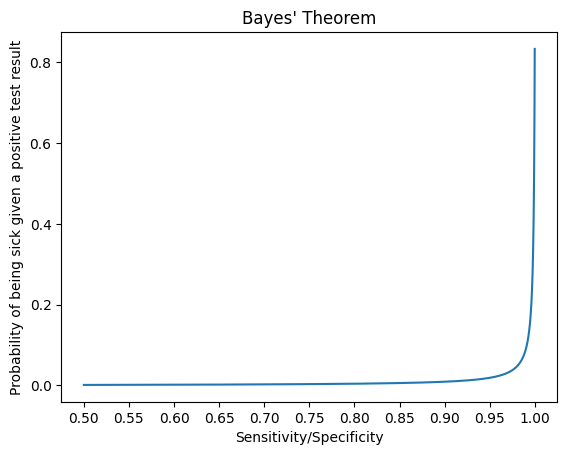

In [46]:
x = np.arange(0.50, 0.9999, 0.0001)
y = [bayes(sensitivity=prob, specificity=prob) for prob in x]

plt.plot(x,y)
plt.xticks(np.arange(0.50, 1.01, 0.05))
plt.xlabel("Sensitivity/Specificity")
plt.ylabel("Probability of being sick given a positive test result")
plt.title("Bayes' Theorem")
plt.show()

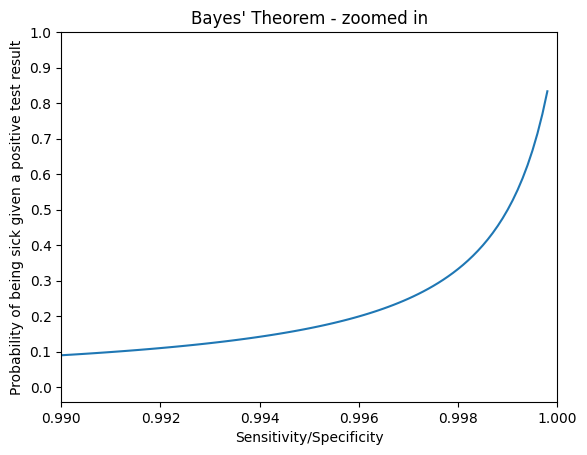

In [57]:
plt.plot(x, y)
plt.xlim(0.99, 1)
plt.yticks(np.arange(0.0, 1.01, 0.1))
plt.xlabel("Sensitivity/Specificity")
plt.ylabel("Probability of being sick given a positive test result")
plt.title("Bayes' Theorem - zoomed in")
plt.show()

### Zadanie 2

Sprawdź (symulacją) ile średnio razy należy losować 13 kart, aby trafia się "ręka" zawierająca $\ge 8$ kart w jednym kolorze. Możemy to zrobić następująco: losujemy 13 kart z 52 (wiec "ręki" jak w brydzu) tak długo, aż w którymkolwiek kolorze dostaniemy $\ge 8$ kart, zapisujemy liczbę przeprowadzonych losowań i podejmujemy kolejną próbę. Przeprowadź 1000 takich prób i oblicz średnią liczbę losowań. 

Dodatkowo wypisz jedną (np. ostatnią) wylosowaną "rękę".

In [83]:
def count_colors(cards):
    suits = {
        "hearts": 0,
        "diamonds": 0,
        "clubs": 0,
        "spades": 0      
    }
    for card in cards:
        if card < 13:
            suits["hearts"] += 1
        elif card < 26:
            suits["diamonds"] += 1
        elif card < 39:
            suits["clubs"] += 1
        else:
            suits["spades"] += 1
            
    flag = False
    for suit in suits:
        if suits[suit] >= 8:
            flag = True
            break
    return flag


all_tries = 0
last_hand = []
num_of_retries = 10_000
for _ in range(num_of_retries):
    tries = 0
    cards = [i for i in range(0, 52)]
    while True:
        random.shuffle(cards)
        choosen_cards = cards[:13]
        if count_colors(choosen_cards):
            last_hand = choosen_cards
            break
        tries += 1
        
    all_tries += tries
    
print(f"Average number of tries to get 8 cards of the same color: {all_tries/num_of_retries}")
print(f"Last hand: {sorted(last_hand)}")

Average number of tries to get 8 cards of the same color: 196.1071
Last hand: [16, 17, 20, 27, 28, 30, 31, 35, 36, 37, 38, 42, 44]
